# Planetary-dominated eddies: vertical background flow and tilt

This notebook asks whether depth-dependent environmental flow can explain the shared zonal component of planetary-dominated eddy tilt, while the beta effect explains the opposite meridional components. It uses exactly the same 2:1 planetary-dominance, 3000 m minimum depth, and 5 km minimum tilt criteria as `plan_topo_dom_eddies/planetary_dominated_eddies.ipynb`.

`TiltDir` is a compass bearing **from the deep centre to the shallow centre** (0° north, 90° east). Therefore the kinematic predictor is shallow flow minus deep flow. A deeper layer flowing farther west than the surface gives a positive/eastward predictor, matching an eastward shallow-relative-to-deep tilt.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
import statsmodels.formula.api as smf

HERE = Path.cwd().resolve()
ANALYSIS_ROOT = next((p for p in (HERE, *HERE.parents) if (p / 'seacofs_tilt_tools.py').exists()), None)
if ANALYSIS_ROOT is None:
    raise FileNotFoundError('Run from seacofs_eddy_tilt_analysis or one of its subfolders.')
FLOW_ROOT = ANALYSIS_ROOT / 'beta_effect_background_flow'
CASE_ROOT = ANALYSIS_ROOT / 'case_studies'
for path in (ANALYSIS_ROOT, FLOW_ROOT, CASE_ROOT):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import seacofs_tilt_tools as tilt
from analysis_tools import add_track_velocity
from background_flow_tools import BackgroundConfig, load_background_cache
from vertical_propagation_tools import interpolate_centres, add_depth_propagation, wide_depth_propagation
from case_study_tools import PVAlignmentConfig, add_pv_alignment_diagnostics

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 100)

## 1. Settings and exact planetary-dominated sample

In [2]:
DOMINANCE_FACTOR = 2.0
MIN_DEPTH_m = 3000.0
MIN_TILT_km = 5.0
PRIMARY_FAMILY = 'clim'      # centred 91-day moving seasonal climatology
FAMILIES = ('clim', 'full')
N_BOOT = 5000
RANDOM_SEED = 42

paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)
eddies, _ = tilt.load_tilt_tables(paths)
eddies = tilt.add_region_labels(eddies, grid)
eddies = tilt.add_pv_gradient_terms(eddies, grid, core_mean=True)

# Calculate track derivatives before filtering so boundary days are not created artificially.
eddies = add_track_velocity(eddies, grid.angle, window=5)
background = load_background_cache(BackgroundConfig())
required = {f'{family}_{depth}_{component}_ms' for family in FAMILIES
            for depth in ('surface', '200', '500') for component in ('east', 'north')}
missing = required - set(background.columns)
if missing:
    raise RuntimeError(f'Background cache is missing {sorted(missing)}. Run 01_build_background_cache.ipynb first.')
# d = eddies.merge(background, on=['Eddy', 'Day'], how='inner', validate='one_to_one')
background_for_merge = background.drop(columns=['ic', 'jc'], errors='ignore')
d = eddies.merge(background_for_merge, on=['Eddy', 'Day'], how='inner', validate='one_to_one')
pv_config = PVAlignmentConfig(dominance_factor=DOMINANCE_FACTOR,
                              min_open_ocean_depth_m=MIN_DEPTH_m,
                              min_tilt_distance_km=MIN_TILT_km)
d = add_pv_alignment_diagnostics(d, pv_config)
planetary = d[d.open_ocean_planetary & d.direction_valid].copy()
planetary = planetary.sort_values(['Eddy', 'Day']).copy()
# Retained days can form disconnected planetary-dominant episodes within one eddy.
planetary['planetary_episode'] = planetary.groupby('Eddy')['Day'].diff().gt(1).groupby(planetary.Eddy).cumsum().astype(int)
theta = np.deg2rad(planetary.TiltDir.astype(float))
planetary['tilt_east_km'] = planetary.TiltDis * np.sin(theta)
planetary['tilt_north_km'] = planetary.TiltDis * np.cos(theta)
display(planetary.groupby('Cyc').agg(observations=('Eddy','size'), eddies=('Eddy','nunique'),
    episodes=('planetary_episode', lambda x: planetary.loc[x.index, ['Eddy','planetary_episode']].drop_duplicates().shape[0]),
    median_depth_m=('h','median'), median_tilt_east_km=('tilt_east_km','median'),
    median_tilt_north_km=('tilt_north_km','median')).round(2))

,observations,eddies,episodes,median_depth_m,median_tilt_east_km,median_tilt_north_km
Cyc,,,,,,
AE,5184,364,687,4837.76,2.51,6.02
CE,1069,146,180,4853.47,5.16,-9.72


## 2. Construct physically interpretable layers and shear

The cache contains a surface value and thickness-weighted 0–200 m and 0–500 m means. Because every selected water column is deeper than 3000 m, the 200–500 m mean can be recovered as `(500 × mean_0_500 − 200 × mean_0_200) / 300`. This is a **layer mean**, not a velocity at a single sigma or z level.

The principal predictor is `surface − 200–500 m`, because the measured tilt points from deep to shallow. Positive east shear predicts eastward tilt; positive north shear predicts northward tilt. `clim` is the centred 91-day moving seasonal climatology and is the primary environmental-flow estimate; `full` is the full 26-year mean sensitivity test. The annulus method is excluded.

In [3]:
for family in FAMILIES:
    for component in ('east', 'north'):
        surface = f'{family}_surface_{component}_ms'
        upper = f'{family}_200_{component}_ms'
        full500 = f'{family}_500_{component}_ms'
        deep = f'{family}_200_500_{component}_ms'
        planetary[deep] = (500 * planetary[full500] - 200 * planetary[upper]) / 300
        planetary[f'{family}_surface_minus_200_{component}_ms'] = planetary[surface] - planetary[upper]
        planetary[f'{family}_surface_minus_deep_{component}_ms'] = planetary[surface] - planetary[deep]
        planetary[f'{family}_upper_minus_deep_{component}_ms'] = planetary[upper] - planetary[deep]
        # These are track velocities relative to different environmental references,
        # not independent measurements of the shallow and deep eddy-centre motion.
        planetary[f'{family}_surface_residual_{component}_ms'] = planetary[f'track_{component}_ms'] - planetary[surface]
        planetary[f'{family}_deep_residual_{component}_ms'] = planetary[f'track_{component}_ms'] - planetary[deep]

depth_labels = {'surface': 'Surface', '200': '0–200 m', '200_500': '200–500 m'}
planetary.filter(regex='^(Eddy|Day|Cyc|Tilt|tilt_|clim_.*(east|north)_ms)$').head()

,Eddy,Day,Cyc,clim_surface_east_ms,clim_surface_north_ms,clim_200_east_ms,clim_200_north_ms,clim_500_east_ms,clim_500_north_ms,clim_200_500_east_ms,clim_surface_minus_200_east_ms,clim_surface_minus_deep_east_ms,clim_upper_minus_deep_east_ms,clim_surface_residual_east_ms,clim_deep_residual_east_ms,clim_200_500_north_ms,clim_surface_minus_200_north_ms,clim_surface_minus_deep_north_ms,clim_upper_minus_deep_north_ms,clim_surface_residual_north_ms,clim_deep_residual_north_ms
158,6,1465,AE,0.081333,0.011343,0.059480,0.037867,0.039407,0.031878,0.026024,0.021853,0.055308,0.033455,-0.048632,0.006676,0.027885,-0.026524,-0.016542,0.009982,0.020001,0.003458
159,6,1466,AE,0.064961,-0.008974,0.045286,0.020039,0.028523,0.017809,0.017348,0.019675,0.047613,0.027938,-0.080358,-0.032745,0.016323,-0.029013,-0.025297,0.003716,0.057823,0.032527
160,6,1467,AE,0.072867,-0.015649,0.053002,0.014625,0.033558,0.014060,0.020595,0.019864,0.052271,0.032407,-0.088264,-0.035992,0.013683,-0.030274,-0.029332,0.000942,0.064498,0.035166
161,6,1468,AE,0.025780,-0.076440,0.011044,-0.038365,0.000427,-0.028040,-0.006652,0.014736,0.032432,0.017696,-0.041177,-0.008745,-0.021156,-0.038075,-0.055283,-0.017208,0.125289,0.070006
162,6,1469,AE,0.016842,-0.079676,0.003836,-0.041382,-0.004417,-0.030974,-0.009919,0.013006,0.026761,0.013755,-0.048327,-0.021566,-0.024036,-0.038294,-0.055640,-0.017346,0.137370,0.081729


## 3. Flow at each depth

The bars summarize all qualifying planetary-dominant eddy-days. Confidence intervals use an eddy-cluster bootstrap: an entire eddy's retained observations—including any disconnected planetary episodes—are resampled together. No post-filter per-eddy mean or median is taken. Compare AE and CE at each depth.

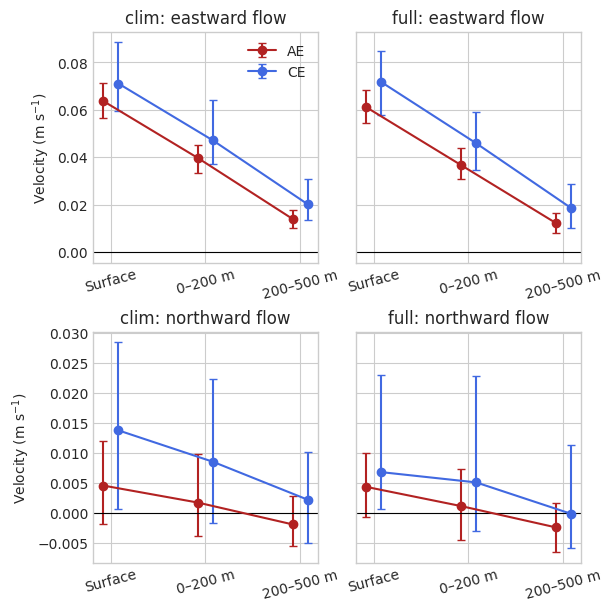

In [4]:
def cluster_bootstrap_median(frame, column, cluster='Eddy', n_boot=N_BOOT, seed=RANDOM_SEED):
    q = frame[[cluster, column]].dropna()
    clusters = {key: part[column].to_numpy(float) for key, part in q.groupby(cluster)}
    keys = np.asarray(list(clusters))
    if not len(keys):
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    boot = np.empty(n_boot)
    for b in range(n_boot):
        sampled = rng.choice(keys, len(keys), replace=True)
        boot[b] = np.median(np.concatenate([clusters[key] for key in sampled]))
    estimate = np.median(q[column])
    return estimate, *np.percentile(boot, [2.5, 97.5])

def depth_summary(frame, family):
    rows = []
    for component in ('east', 'north'):
        for depth in depth_labels:
            col = f'{family}_{depth}_{component}_ms'
            for cyc, part in frame.groupby('Cyc'):
                med, lo, hi = cluster_bootstrap_median(part, col, seed=RANDOM_SEED + len(rows))
                rows.append(dict(family=family, component=component, depth=depth, Cyc=cyc,
                                 observations=part[col].notna().sum(), eddies=part.loc[part[col].notna(),'Eddy'].nunique(),
                                 median=med, ci_low=lo, ci_high=hi))
    return pd.DataFrame(rows)

flow_summary = pd.concat([depth_summary(planetary, f) for f in FAMILIES], ignore_index=True)
# display(flow_summary.round(4))

fig, axes = plt.subplots(2, 2, figsize=(6, 6), sharey='row', constrained_layout=True)
colors = {'AE': 'firebrick', 'CE': 'royalblue'}
for j, family in enumerate(FAMILIES):
    for i, component in enumerate(('east', 'north')):
        ax = axes[i, j]
        part = flow_summary.query('family == @family and component == @component')
        for offset, cyc in zip((-0.08, 0.08), ('AE', 'CE')):
            q = part[part.Cyc.eq(cyc)].set_index('depth').reindex(depth_labels)
            x = np.arange(3) + offset
            ax.errorbar(x, q['median'], yerr=[q['median']-q['ci_low'], q['ci_high']-q['median']],
                        fmt='o-', capsize=3, color=colors[cyc], label=cyc)
        ax.axhline(0, color='k', lw=.8)
        ax.set_xticks(range(3), depth_labels.values(), rotation=15)
        ax.set_title(f'{family}: {component}ward flow')
        if j == 0: ax.set_ylabel('Velocity (m s$^{-1}$)')
        if i == 0 and j == 0: ax.legend()
plt.show()

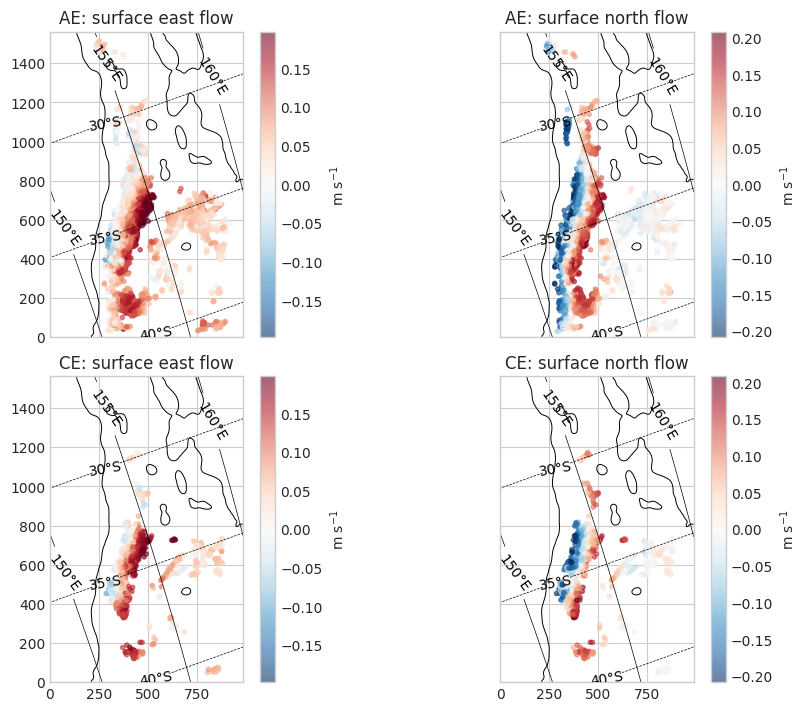

In [66]:
fig, axes = plt.subplots(2, 2, figsize=(9, 7), sharex=True, sharey=True, constrained_layout=True)
family = 'clim'
depth = 'surface'
for i, cyc in enumerate(('AE', 'CE')):
    q = planetary[planetary.Cyc.eq(cyc)]
    for j, title in enumerate(('east', 'north')):
        col = f'{family}_{depth}_{title}_ms'
        ax = axes[i, j]
        lim = np.nanpercentile(np.abs(planetary[col]), 98)
        sc = ax.scatter(q.xc, q.yc, c=q[col], s=9, alpha=.6, cmap='RdBu_r', vmin=-lim, vmax=lim)
        ax.contour(grid.X_grid, grid.Y_grid, grid.h, levels=[MIN_DEPTH_m], colors='k', linewidths=.7)
        tilt.lat_lon_contours(ax, grid)
        ax.set_title(f'{cyc}: {depth} {title} flow')
        ax.set_aspect('equal', adjustable='box')
        fig.colorbar(sc, ax=ax, label='m s$^{-1}$')
plt.show()

In [70]:
planetary['clim_surface_north_ms'].describe()

count    6253.000000
mean        0.006034
std         0.090665
min        -0.333385
25%        -0.044052
50%         0.005887
75%         0.075562
max         0.243298
Name: clim_surface_north_ms, dtype: float64

## 4. Does surface-minus-deep shear have the observed tilt direction?

The first panel compares the AE/CE median shear vectors with the observed tilt vectors across qualifying planetary-dominant observations. Arrow directions, rather than lengths, are directly comparable because velocity and displacement have different units. The second and third panels show the observation-level zonal and meridional relationships; formal uncertainty is clustered by eddy in the next section.

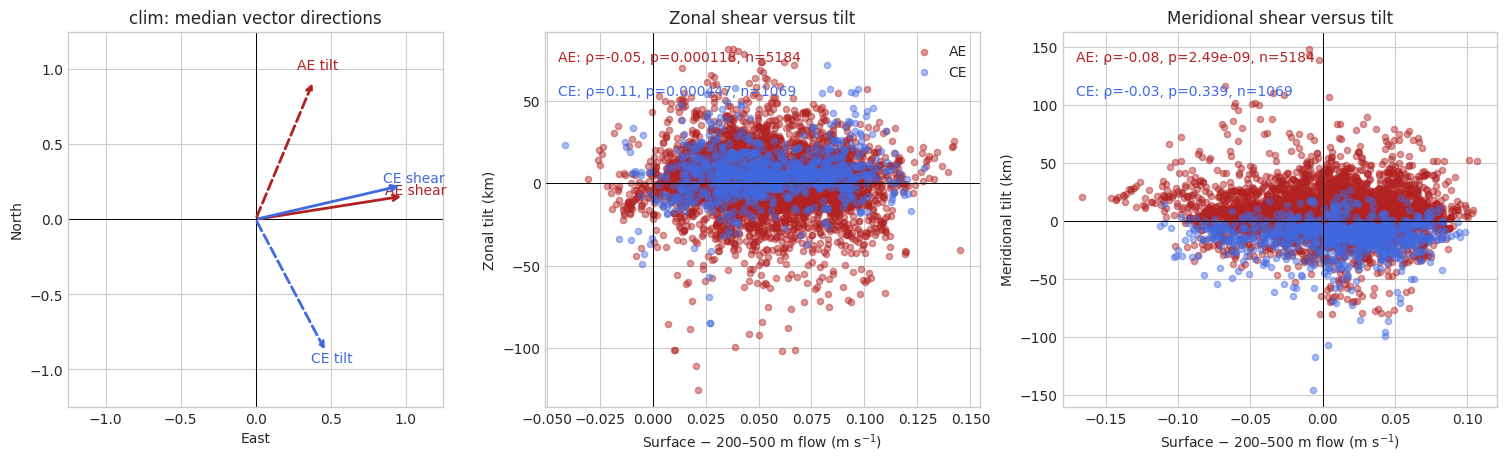

In [8]:
family = PRIMARY_FAMILY
shear_e = f'{family}_surface_minus_deep_east_ms'
shear_n = f'{family}_surface_minus_deep_north_ms'
cols = ['tilt_east_km', 'tilt_north_km', shear_e, shear_n]
eddy_level = planetary

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)
ax = axes[0]
for cyc in ('AE', 'CE'):
    q = eddy_level[eddy_level.Cyc.eq(cyc)]
    se, sn = q[[shear_e, shear_n]].median()
    te, tn = q[['tilt_east_km', 'tilt_north_km']].median()
    # Normalize each arrow: this panel compares direction only.
    for e, n, ls, label in ((se, sn, '-', f'{cyc} shear'), (te, tn, '--', f'{cyc} tilt')):
        norm = np.hypot(e, n)
        ax.annotate('', xy=(e/norm, n/norm), xytext=(0, 0),
                    arrowprops=dict(arrowstyle='->', color=colors[cyc], lw=2, linestyle=ls))
        ax.text(e/norm*1.08, n/norm*1.08, label, color=colors[cyc], ha='center')
ax.axhline(0, color='k', lw=.7); ax.axvline(0, color='k', lw=.7)
ax.set(xlim=(-1.25,1.25), ylim=(-1.25,1.25), aspect='equal', xlabel='East', ylabel='North',
       title=f'{family}: median vector directions')

for ax, xcol, ycol, label in ((axes[1], shear_e, 'tilt_east_km', 'zonal'),
                                  (axes[2], shear_n, 'tilt_north_km', 'meridional')):
    for cyc in ('AE', 'CE'):
        q = eddy_level[eddy_level.Cyc.eq(cyc)]
        ax.scatter(q[xcol], q[ycol], s=20, alpha=.45, color=colors[cyc], label=cyc)
        valid = q[[xcol, ycol]].dropna()
        rho, p = spearmanr(valid[xcol], valid[ycol]) if len(valid) > 2 else (np.nan, np.nan)
        ax.text(.03, .95-(.09 if cyc == 'CE' else 0), f'{cyc}: ρ={rho:.2f}, p={p:.3g}, n={len(valid)}',
                transform=ax.transAxes, va='top', color=colors[cyc])
    ax.axhline(0, color='k', lw=.7); ax.axvline(0, color='k', lw=.7)
    ax.set_xlabel('Surface − 200–500 m flow (m s$^{-1}$)')
    ax.set_ylabel(f'{label.capitalize()} tilt (km)')
    ax.set_title(f'{label.capitalize()} shear versus tilt')
axes[1].legend()
plt.show()

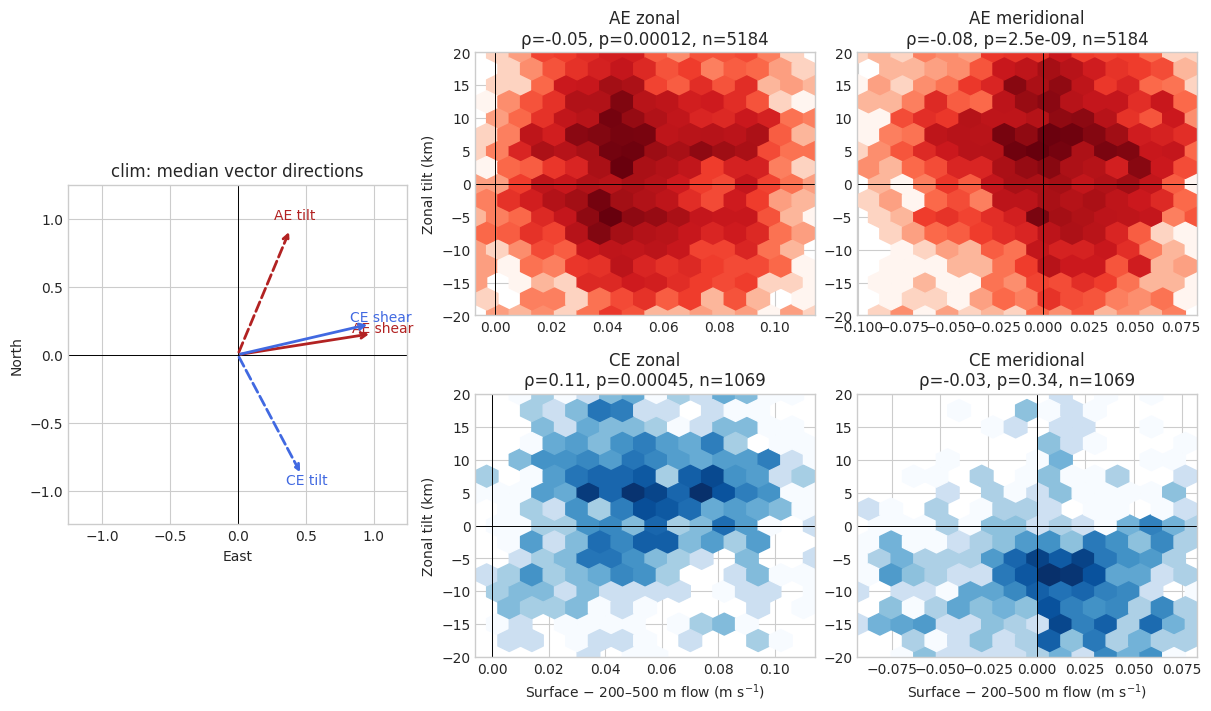

In [9]:
family = PRIMARY_FAMILY
shear_e = f'{family}_surface_minus_deep_east_ms'
shear_n = f'{family}_surface_minus_deep_north_ms'
eddy_level = planetary

fig = plt.figure(figsize=(12, 7), constrained_layout=True)
gs = fig.add_gridspec(2, 3)
ax0 = fig.add_subplot(gs[:, 0])
axs = np.array([[fig.add_subplot(gs[0, 1]), fig.add_subplot(gs[0, 2])],
                [fig.add_subplot(gs[1, 1]), fig.add_subplot(gs[1, 2])]])

# Median vector directions
for cyc in ('AE', 'CE'):
    q = eddy_level[eddy_level.Cyc.eq(cyc)]
    se, sn = q[[shear_e, shear_n]].median()
    te, tn = q[['tilt_east_km', 'tilt_north_km']].median()

    for e, n, ls, label in ((se, sn, '-', f'{cyc} shear'),
                            (te, tn, '--', f'{cyc} tilt')):
        norm = np.hypot(e, n)
        ax0.annotate('', xy=(e/norm, n/norm), xytext=(0, 0),
                     arrowprops=dict(arrowstyle='->', color=colors[cyc],
                                     lw=2, linestyle=ls))
        ax0.text(e/norm*1.08, n/norm*1.08, label,
                 color=colors[cyc], ha='center')

ax0.axhline(0, color='k', lw=.7)
ax0.axvline(0, color='k', lw=.7)
ax0.set(xlim=(-1.25, 1.25), ylim=(-1.25, 1.25), aspect='equal',
        xlabel='East', ylabel='North',
        title=f'{family}: median vector directions')

# Hexbin distributions
tilt_lim_obs = 20
for row, cyc in enumerate(('AE', 'CE')):
    for col, (xcol, ycol, label) in enumerate((
            (shear_e, 'tilt_east_km', 'Zonal'),
            (shear_n, 'tilt_north_km', 'Meridional'))):

        ax = axs[row, col]
        q = eddy_level.loc[eddy_level.Cyc.eq(cyc), [xcol, ycol]].dropna()

        # Construct finer hexbins over the main distribution
        xlo, xhi = q[xcol].quantile([.01, .99])

        ax.hexbin(q[xcol], q[ycol], gridsize=15, mincnt=1, bins='log',
                  extent=[xlo, xhi, -tilt_lim_obs, tilt_lim_obs],
                  cmap='Reds' if cyc == 'AE' else 'Blues')

        # Statistics still use the full dataset
        rho, p = spearmanr(q[xcol], q[ycol])

        ax.axhline(0, color='k', lw=.7)
        ax.axvline(0, color='k', lw=.7)
        ax.set(xlim=(xlo, xhi), ylim=(-tilt_lim_obs, tilt_lim_obs))
        ax.set_title(f'{cyc} {label.lower()}\n'
                     f'ρ={rho:.2f}, p={p:.2g}, n={len(q)}')

        if row == 1:
            ax.set_xlabel('Surface − 200–500 m flow (m s$^{-1}$)')
        if col == 0:
            ax.set_ylabel(f'{label} tilt (km)')

plt.show()

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(15, 5), constrained_layout=True)
colors = {'AE':'firebrick', 'CE':'royalblue'}
family, depth = 'clim', 'surface'

# Summary
ax = axes[0]
for comp, fmt in {'east':'o-', 'north':'s--'}.items():
    part = flow_summary.query('family == @family and component == @comp')
    for off, cyc in zip((-.08,.08), ('AE','CE')):
        q = part[part.Cyc.eq(cyc)].set_index('depth').reindex(depth_labels)
        lbl = 'zonal' if comp=='east' else 'meridonal'
        ax.errorbar(np.arange(3)+off, q['median'],
                    yerr=[q['median']-q['ci_low'], q['ci_high']-q['median']],
                    fmt=fmt, capsize=3, color=colors[cyc], label=f'{cyc} {lbl}')
ax.axhline(0, color='k', lw=.8)
ax.set_xticks(range(3), depth_labels.values(), rotation=15)
ax.set_ylabel('Background flow (m s$^{-1}$)')
ax.legend()

# Maps: AE east, CE east, AE north, CE north
panels = [('AE','east'), ('CE','east'), ('AE','north'), ('CE','north')]
cols = [f'{family}_{depth}_{c}_ms' for _, c in panels]
lim = np.nanpercentile(np.abs(planetary[cols].values), 98)

for k, (ax, (cyc, comp)) in enumerate(zip(axes[1:], panels)):
    q = planetary[planetary.Cyc.eq(cyc)].copy()
    col = f'{family}_{depth}_{comp}_ms'
    q = q.iloc[np.argsort(q[col].abs())]
    sc = ax.scatter(q.xc, q.yc, c=q[f'{family}_{depth}_{comp}_ms'],
                    s=9, alpha=.7, cmap='PiYG', vmin=-lim, vmax=lim)
    ax.contour(grid.X_grid, grid.Y_grid, grid.h, [MIN_DEPTH_m], colors='k', linewidths=.7)
    tilt.lat_lon_contours(ax, grid, land_mask=True, land_clr=colors[cyc])
    ax.text(30, 830, f'{cyc}', fontsize=20, fontweight='bold', color='w')
    if k != 0:
        ax.set_yticklabels('')
    else:
        ax.set_ylabel('y (km)')
    ax.set_xlabel('x (km)')
    lbl = 'zonal' if comp=='east' else 'meridonal'
    ax.set_title(f'{cyc} {lbl}')
    ax.set_aspect('equal')

fig.colorbar(sc, ax=axes[1:], label='Surface - bottom flow (m s$^{-1})$', shrink=.7)
plt.show()

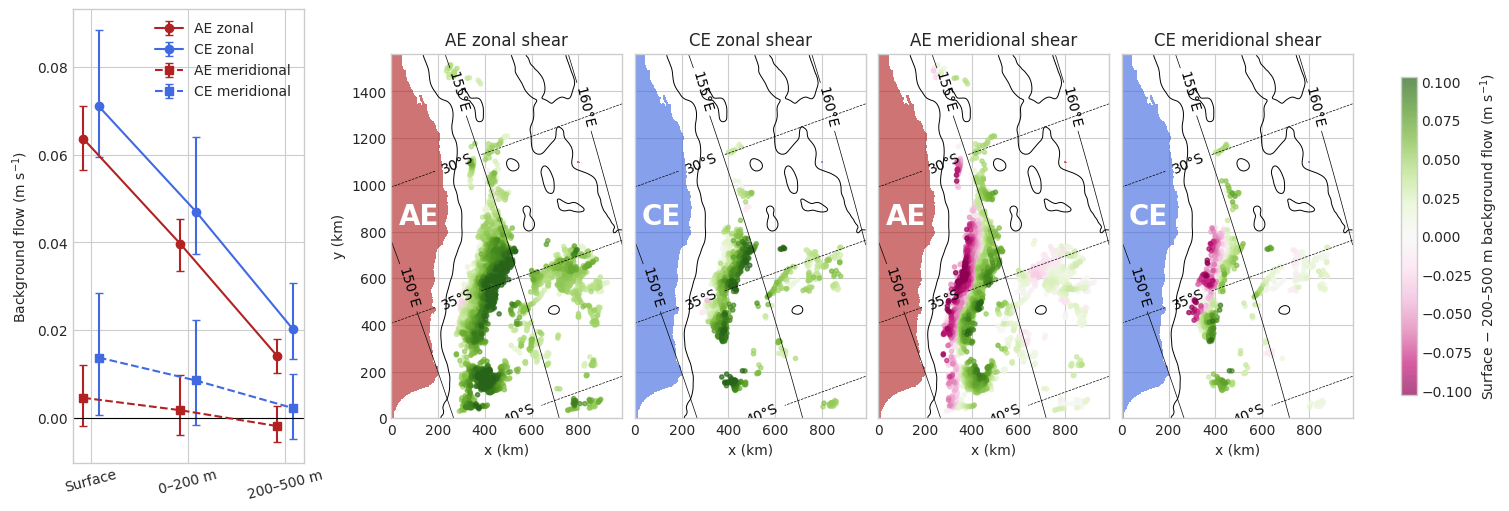

In [42]:
fig, axes = plt.subplots(1, 5, figsize=(15, 5), constrained_layout=True)
colors = {'AE':'firebrick', 'CE':'royalblue'}
family = 'clim'

# Summary
ax = axes[0]
for comp, fmt in {'east':'o-', 'north':'s--'}.items():
    p = flow_summary.query('family == @family and component == @comp')
    for off, cyc in zip((-.08,.08), ('AE','CE')):
        q = p[p.Cyc.eq(cyc)].set_index('depth').reindex(depth_labels)
        m = q['median']
        ax.errorbar(np.arange(3)+off, m, [m-q.ci_low, q.ci_high-m],
                    fmt=fmt, capsize=3, color=colors[cyc],
                    label=f"{cyc} {'zonal' if comp=='east' else 'meridional'}")
ax.axhline(0, color='k', lw=.8)
ax.set(xticks=range(3), ylabel='Background flow (m s$^{-1}$)')
ax.set_xticklabels(depth_labels.values(), rotation=15)
ax.legend()

# Maps
panels = [('AE','east'), ('CE','east'), ('AE','north'), ('CE','north')]
cols = [f'{family}_surface_minus_deep_{c}_ms' for _, c in panels]
lim = np.nanpercentile(np.abs(planetary[cols]), 98)

for k, (ax, (cyc, comp)) in enumerate(zip(axes[1:], panels)):
    col = f'{family}_surface_minus_deep_{comp}_ms'
    q = planetary[planetary.Cyc.eq(cyc)].sort_values(col, key=abs)
    sc = ax.scatter(q.xc, q.yc, c=q[col], s=9, alpha=.7,
                    cmap='PiYG', vmin=-lim, vmax=lim)
    ax.contour(grid.X_grid, grid.Y_grid, grid.h, [MIN_DEPTH_m], colors='k', linewidths=.7)
    tilt.lat_lon_contours(ax, grid, land_mask=True, land_clr=colors[cyc])
    ax.text(30, 830, cyc, fontsize=20, weight='bold', color='w')
    ax.set(xlabel='x (km)', ylabel='y (km)' if k==0 else '',
           title=f"{cyc} {'zonal' if comp=='east' else 'meridional'} shear", aspect='equal')
    if k: ax.set_yticklabels('')

fig.colorbar(sc, ax=axes[1:],
             label='Surface − 200–500 m background flow (m s$^{-1}$)', shrink=.7)

<Axes: >

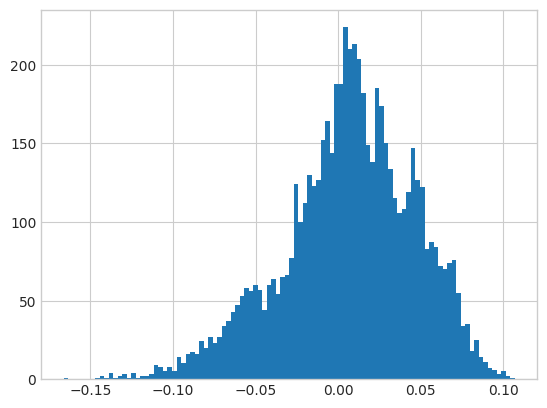

In [64]:
planetary[f'{family}_surface_minus_deep_north_ms'].hist(bins=100)

In [62]:
downward_stream = planetary[planetary[f'{family}_surface_minus_deep_north_ms']<0].copy()
for cyc in ['AE', 'CE']:
    df = downward_stream[downward_stream.Cyc==cyc].copy()
    print(cyc, df.tilt_north_km.median())

upward_stream = planetary[planetary[f'{family}_surface_minus_deep_north_ms']>0].copy()
for cyc in ['AE', 'CE']:
    df = upward_stream[upward_stream.Cyc==cyc].copy()
    print(cyc, df.tilt_north_km.median())

AE 6.902090572047827
CE -8.954365602654535


In [63]:
upward_stream = planetary[planetary[f'{family}_surface_minus_deep_north_ms']>0].copy()
for cyc in ['AE', 'CE']:
    df = upward_stream[upward_stream.Cyc==cyc].copy()
    print(cyc, df.tilt_north_km.median())


AE 5.507682067856827
CE -10.220438095611707


## 5. Does vertical background-flow shear explain the tilt?

This section separates four levels of evidence: the directions of shear and tilt, their sign concordance, the same-day magnitude relationship, and whether shear precedes a subsequent change in tilt. The zonal hypothesis is primary and the meridional test is secondary. Positive raw northward shear is expected to make raw northward tilt more positive for both polarities: strengthening AE northward tilt but weakening CE southward tilt.

Every qualifying eddy-day is retained. Confidence intervals resample whole eddies, GEE uncertainty is clustered by `Eddy`, and tilt tendencies never bridge disconnected planetary-dominant episodes. These observational associations can support a shear mechanism but cannot alone establish causation.

In [ ]:
def cluster_bootstrap_correlation(frame, x, y, cluster='Eddy', n_boot=N_BOOT, seed=RANDOM_SEED):
    q = frame[[cluster, x, y]].dropna()
    clusters = {key: part[[x, y]].to_numpy(float) for key, part in q.groupby(cluster)}
    keys = np.asarray(list(clusters))
    if len(keys) < 3:
        return np.nan, np.nan, np.nan
    observed = spearmanr(q[x], q[y]).statistic
    rng = np.random.default_rng(seed)
    boot = np.empty(n_boot)
    for b in range(n_boot):
        sampled = rng.choice(keys, len(keys), replace=True)
        sample = np.concatenate([clusters[key] for key in sampled])
        boot[b] = spearmanr(sample[:, 0], sample[:, 1]).statistic
    return observed, *np.nanpercentile(boot, [2.5, 97.5])

def cluster_bootstrap_proportion(frame, value, cluster='Eddy', n_boot=N_BOOT, seed=RANDOM_SEED):
    q = frame[[cluster, value]].dropna()
    clusters = {key: part[value].to_numpy(float) for key, part in q.groupby(cluster)}
    keys = np.asarray(list(clusters))
    if not len(keys): return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    boot = np.empty(n_boot)
    for b in range(n_boot):
        sampled = rng.choice(keys, len(keys), replace=True)
        boot[b] = np.concatenate([clusters[key] for key in sampled]).mean()
    return q[value].mean(), *np.nanpercentile(boot, [2.5, 97.5])

ii = planetary['ic'].astype(int).clip(0, grid.lat_rho.shape[0] - 1).to_numpy()
jj = planetary['jc'].astype(int).clip(0, grid.lat_rho.shape[1] - 1).to_numpy()
planetary['latitude'] = grid.lat_rho[ii, jj]

# Direction, magnitude, and sign-concordance summaries.
direction_rows = []
for family in FAMILIES:
    for component in ('east', 'north'):
        shear = f'{family}_surface_minus_deep_{component}_ms'
        tilt_component = f'tilt_{component}_km'
        for cyc in ('AE', 'CE'):
            q = planetary.loc[planetary.Cyc.eq(cyc), ['Eddy', shear, tilt_component]].dropna().copy()
            q['same_sign'] = (np.sign(q[shear]) == np.sign(q[tilt_component])).astype(float)
            smed, slo, shi = cluster_bootstrap_median(q, shear, seed=RANDOM_SEED + len(direction_rows))
            tmed, tlo, thi = cluster_bootstrap_median(q, tilt_component, seed=RANDOM_SEED + 100 + len(direction_rows))
            agree, alo, ahi = cluster_bootstrap_proportion(q, 'same_sign', seed=RANDOM_SEED + 200 + len(direction_rows))
            rho, rlo, rhi = cluster_bootstrap_correlation(q, shear, tilt_component, seed=RANDOM_SEED + 300 + len(direction_rows))
            direction_rows.append(dict(family=family, component=component, Cyc=cyc, observations=len(q),
                eddies=q.Eddy.nunique(), median_shear_ms=smed, shear_ci_low=slo, shear_ci_high=shi,
                median_tilt_km=tmed, tilt_ci_low=tlo, tilt_ci_high=thi, same_sign_fraction=agree,
                same_sign_ci_low=alo, same_sign_ci_high=ahi, spearman_rho=rho, rho_ci_low=rlo, rho_ci_high=rhi))
direction_summary = pd.DataFrame(direction_rows)
display(direction_summary.round(4))

def gee_component_slopes(frame, response, predictor, family, component):
    use = frame[['Eddy', 'Cyc', 'latitude', response, predictor]].dropna().rename(columns={response:'response', predictor:'shear_ms'})
    fit = smf.gee('response ~ shear_ms * C(Cyc) + bs(latitude, df=4)', groups='Eddy', data=use).fit()
    names = list(fit.params.index); rows = []
    for cyc in ('AE', 'CE'):
        contrast = np.zeros(len(names)); contrast[names.index('shear_ms')] = 1
        interaction = 'shear_ms:C(Cyc)[T.CE]'
        if cyc == 'CE' and interaction in names: contrast[names.index(interaction)] = 1
        test = fit.t_test(contrast); ci = np.asarray(test.conf_int()).ravel()
        part = use[use.Cyc.eq(cyc)]
        rows.append(dict(family=family, component=component, Cyc=cyc, observations=len(part), eddies=part.Eddy.nunique(),
            slope_per_ms=float(np.asarray(test.effect).item()), ci_low=float(ci[0]), ci_high=float(ci[1]),
            p_value=float(np.asarray(test.pvalue).item())))
    return rows

model_rows = []
for family in FAMILIES:
    for component in ('east', 'north'):
        shear = f'{family}_surface_minus_deep_{component}_ms'
        model_rows.extend(gee_component_slopes(planetary, f'tilt_{component}_km', shear, family, component))
same_day_models = pd.DataFrame(model_rows)
display(same_day_models.round(4))
print('Predicted sign: positive slopes for AE and CE in both raw geographic components.')

# Directional evidence plot.
primary = direction_summary.query('family == @PRIMARY_FAMILY')
fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
specs = [('median_shear_ms','shear_ci_low','shear_ci_high','Surface − deep shear (m s$^{-1}$)',0),
         ('median_tilt_km','tilt_ci_low','tilt_ci_high','Tilt (km)',0),
         ('same_sign_fraction','same_sign_ci_low','same_sign_ci_high','Same-sign fraction',.5)]
for ax, (value, low, high, ylabel, reference) in zip(axes, specs):
    for j, component in enumerate(('east', 'north')):
        for offset, cyc in zip((-.08,.08), ('AE','CE')):
            row = primary.query('component == @component and Cyc == @cyc').iloc[0]
            ax.errorbar(j+offset, row[value], yerr=[[row[value]-row[low]],[row[high]-row[value]]],
                        fmt='o', capsize=3, color=colors[cyc], label=cyc if j == 0 else None)
    ax.axhline(reference, color='k', lw=.8, ls='--' if reference else '-')
    ax.set_xticks((0,1), ('Zonal','Meridional')); ax.set_ylabel(ylabel)
axes[0].legend(); axes[0].set_title('Background shear'); axes[1].set_title('Observed tilt')
axes[2].set_title('Directional concordance'); plt.show()

# Same-day magnitude plots: hexbins plus equal-count bin medians and eddy-cluster CIs.
fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)
for row_index, cyc in enumerate(('AE','CE')):
    for col_index, component in enumerate(('east','north')):
        ax = axes[row_index, col_index]
        x = f'{PRIMARY_FAMILY}_surface_minus_deep_{component}_ms'; y = f'tilt_{component}_km'
        q = planetary.loc[planetary.Cyc.eq(cyc), ['Eddy',x,y]].dropna().copy()
        xlo, xhi = q[x].quantile([.01,.99]); shown = q[q[x].between(xlo,xhi)]
        ax.hexbin(shown[x], shown[y], gridsize=22, mincnt=1, bins='log', cmap='Reds' if cyc=='AE' else 'Blues', alpha=.65)
        q['shear_bin'] = pd.qcut(q[x], 6, duplicates='drop'); binned = []
        for _, part in q.groupby('shear_bin', observed=True):
            med, lo, hi = cluster_bootstrap_median(part, y, n_boot=min(N_BOOT,2000), seed=RANDOM_SEED+len(binned))
            binned.append((part[x].median(),med,lo,hi))
        binned = np.asarray(binned)
        ax.errorbar(binned[:,0], binned[:,1], yerr=[binned[:,1]-binned[:,2],binned[:,3]-binned[:,1]],
                    fmt='o-', color='k', capsize=3, label='Binned median ± clustered CI')
        result = same_day_models.query('family == @PRIMARY_FAMILY and component == @component and Cyc == @cyc').iloc[0]
        ax.axhline(0,color='k',lw=.7); ax.axvline(0,color='k',lw=.7)
        ax.set(xlim=(xlo,xhi), xlabel='Surface − 200–500 m shear (m s$^{-1}$)', ylabel=f'{component.capitalize()}ward tilt (km)')
        ax.set_title(f'{cyc} {component}: slope={result.slope_per_ms:.1f} [{result.ci_low:.1f}, {result.ci_high:.1f}]')
        ax.legend(fontsize=8)
plt.show()

# Temporal test: shear on day t versus tilt change to the next consecutive day in the same planetary episode.
episode_groups = planetary.groupby(['Eddy','planetary_episode'], sort=False)
next_day = episode_groups['Day'].shift(-1); dt_days = next_day - planetary['Day']
for component in ('east','north'):
    next_tilt = episode_groups[f'tilt_{component}_km'].shift(-1)
    tendency = f'tilt_{component}_tendency_km_day'
    planetary[tendency] = (next_tilt - planetary[f'tilt_{component}_km']) / dt_days
    planetary.loc[dt_days.ne(1), tendency] = np.nan
tendency_rows = []
for family in FAMILIES:
    for component in ('east','north'):
        shear = f'{family}_surface_minus_deep_{component}_ms'
        tendency_rows.extend(gee_component_slopes(planetary, f'tilt_{component}_tendency_km_day', shear, family, component))
tendency_models = pd.DataFrame(tendency_rows)
display(tendency_models.round(4))

fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)
for row_index, cyc in enumerate(('AE','CE')):
    for col_index, component in enumerate(('east','north')):
        ax = axes[row_index,col_index]
        x = f'{PRIMARY_FAMILY}_surface_minus_deep_{component}_ms'; y = f'tilt_{component}_tendency_km_day'
        q = planetary.loc[planetary.Cyc.eq(cyc), ['Eddy',x,y]].dropna().copy()
        q['shear_bin'] = pd.qcut(q[x], 6, duplicates='drop'); binned = []
        for _, part in q.groupby('shear_bin', observed=True):
            med, lo, hi = cluster_bootstrap_median(part, y, n_boot=min(N_BOOT,2000), seed=RANDOM_SEED+len(binned))
            binned.append((part[x].median(),med,lo,hi))
        binned = np.asarray(binned)
        ax.errorbar(binned[:,0], binned[:,1], yerr=[binned[:,1]-binned[:,2],binned[:,3]-binned[:,1]],
                    fmt='o-', color=colors[cyc], capsize=3)
        result = tendency_models.query('family == @PRIMARY_FAMILY and component == @component and Cyc == @cyc').iloc[0]
        ax.axhline(0,color='k',lw=.7); ax.axvline(0,color='k',lw=.7)
        ax.set(xlabel='Shear at start of interval (m s$^{-1}$)', ylabel=f'Next-day {component} tilt change (km day$^{{-1}}$)')
        ax.set_title(f'{cyc} {component}: slope={result.slope_per_ms:.1f} [{result.ci_low:.1f}, {result.ci_high:.1f}]')
plt.show()

## 6. Natural/background-relative westward propagation

Negative eastward residual velocity means the tracked eddy propagates westward relative to that background estimate. This checks whether the planetary eddies retain a westward propagation anomaly after removing the flow. However, there is only one tracked horizontal centre velocity per eddy-day: subtracting surface and deep backgrounds does **not** independently observe top and bottom eddy propagation. Consequently, the difference between these residuals is algebraically the negative of the background shear and should not be treated as a second independent shear test.

,family,component,reference,Cyc,median,ci_low,ci_high,observations,eddies
0,clim,east,surface,AE,-0.0735,-0.0806,-0.0666,5184,364
1,clim,east,surface,CE,-0.1077,-0.1257,-0.0892,1069,146
2,clim,east,deep,AE,-0.0228,-0.0278,-0.0181,5184,364
3,clim,east,deep,CE,-0.0535,-0.0659,-0.0413,1069,146
4,clim,north,surface,AE,-0.0159,-0.0260,-0.0063,5184,364
5,clim,north,surface,CE,-0.0372,-0.0550,-0.0194,1069,146
6,clim,north,deep,AE,-0.0067,-0.0129,-0.0010,5184,364
7,clim,north,deep,CE,-0.0244,-0.0396,-0.0092,1069,146
8,full,east,surface,AE,-0.0725,-0.0790,-0.0657,5184,364
9,full,east,surface,CE,-0.1039,-0.1202,-0.0894,1069,146


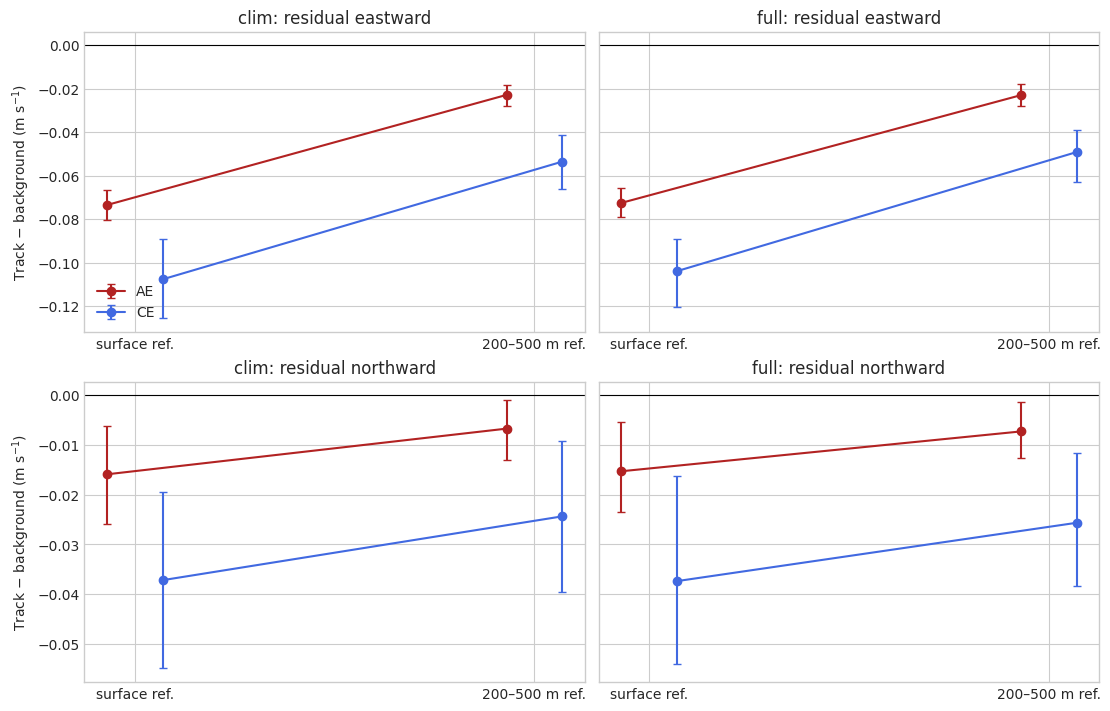

In [12]:
residual_cols = []
for family in FAMILIES:
    residual_cols += [f'{family}_surface_residual_east_ms', f'{family}_deep_residual_east_ms',
                      f'{family}_surface_residual_north_ms', f'{family}_deep_residual_north_ms']
rows = []
for family in FAMILIES:
    for component in ('east', 'north'):
        for reference in ('surface', 'deep'):
            col = f'{family}_{reference}_residual_{component}_ms'
            for cyc, part in planetary.groupby('Cyc'):
                med, lo, hi = cluster_bootstrap_median(part, col, seed=RANDOM_SEED + len(rows))
                rows.append(dict(family=family, component=component, reference=reference, Cyc=cyc,
                                 median=med, ci_low=lo, ci_high=hi, observations=part[col].notna().sum(),
                                 eddies=part.loc[part[col].notna(),'Eddy'].nunique()))
residual_summary = pd.DataFrame(rows)
display(residual_summary.round(4))

fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharey='row', constrained_layout=True)
for j, family in enumerate(FAMILIES):
    for i, component in enumerate(('east', 'north')):
        ax = axes[i, j]
        p = residual_summary.query('family == @family and component == @component')
        for k, cyc in enumerate(('AE', 'CE')):
            q = p[p.Cyc.eq(cyc)].set_index('reference').reindex(['surface','deep'])
            x = np.arange(2) + (-.07 if cyc == 'AE' else .07)
            ax.errorbar(x, q['median'], yerr=[q['median']-q['ci_low'], q['ci_high']-q['median']],
                        fmt='o-', capsize=3, color=colors[cyc], label=cyc)
        ax.axhline(0, color='k', lw=.8)
        ax.set_xticks([0,1], ['surface ref.', '200–500 m ref.'])
        ax.set_title(f'{family}: residual {component}ward')
        if j == 0: ax.set_ylabel('Track − background (m s$^{-1}$)')
        if i == 0 and j == 0: ax.legend()
plt.show()

## 7. Latitude-controlled meridional propagation

The key beta-drift test is the **AE minus CE northward residual-velocity contrast**. A positive contrast means that AEs propagate more equatorward (or less poleward) than CEs. The binned statistic uses all qualifying observations in each latitude band, with whole-eddy cluster bootstrap intervals. The GEE model likewise uses all eddy-days, a flexible latitude spline, and eddy-clustered uncertainty; latitude is the only adjustment variable.

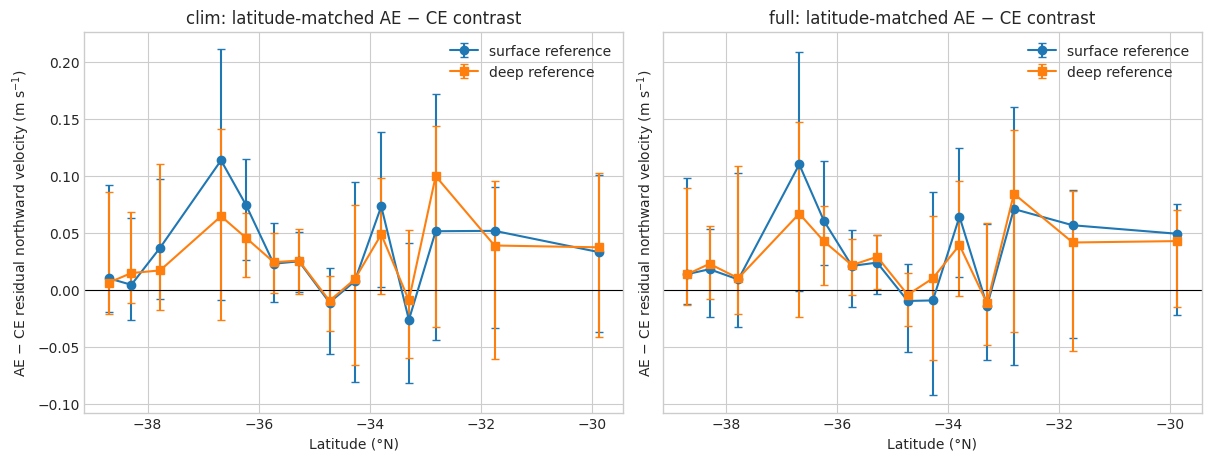

In [13]:
ii = planetary.ic.astype(int).clip(0, grid.lat_rho.shape[0] - 1)
jj = planetary.jc.astype(int).clip(0, grid.lat_rho.shape[1] - 1)
planetary['latitude'] = grid.lat_rho[ii, jj]
LAT_BIN_DEG = .5
lat_edges = np.arange(np.floor(planetary.latitude.min() / LAT_BIN_DEG) * LAT_BIN_DEG,
                      np.ceil(planetary.latitude.max() / LAT_BIN_DEG) * LAT_BIN_DEG + LAT_BIN_DEG,
                      LAT_BIN_DEG)
planetary['latitude_bin'] = pd.cut(planetary.latitude, lat_edges, include_lowest=True)

def cluster_bootstrap_two_group_contrast(a, b, column, n_boot=N_BOOT, seed=RANDOM_SEED):
    a = {key: part[column].dropna().to_numpy(float) for key, part in a.groupby('Eddy')}
    b = {key: part[column].dropna().to_numpy(float) for key, part in b.groupby('Eddy')}
    a, b = {k:v for k,v in a.items() if len(v)}, {k:v for k,v in b.items() if len(v)}
    ka, kb = np.asarray(list(a)), np.asarray(list(b))
    if min(len(ka), len(kb)) < 3:
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    boot = np.empty(n_boot)
    for i in range(n_boot):
        va = np.concatenate([a[k] for k in rng.choice(ka, len(ka), replace=True)])
        vb = np.concatenate([b[k] for k in rng.choice(kb, len(kb), replace=True)])
        boot[i] = np.median(va) - np.median(vb)
    observed = np.median(np.concatenate(list(a.values()))) - np.median(np.concatenate(list(b.values())))
    return observed, *np.percentile(boot, [2.5, 97.5])

latitude_rows = []
for family in FAMILIES:
    for reference in ('surface', 'deep'):
        col = f'{family}_{reference}_residual_north_ms'
        for band, part in planetary.groupby('latitude_bin', observed=True):
            ae, ce = part[part.Cyc.eq('AE')], part[part.Cyc.eq('CE')]
            contrast, lo, hi = cluster_bootstrap_two_group_contrast(
                ae, ce, col, seed=RANDOM_SEED + len(latitude_rows))
            latitude_rows.append(dict(family=family, reference=reference, latitude=part.latitude.median(),
                latitude_bin=str(band), ae_observations=ae[col].notna().sum(), ce_observations=ce[col].notna().sum(),
                ae_eddies=ae.loc[ae[col].notna(),'Eddy'].nunique(), ce_eddies=ce.loc[ce[col].notna(),'Eddy'].nunique(),
                ae_median=ae[col].median(), ce_median=ce[col].median(), ae_minus_ce=contrast, ci_low=lo, ci_high=hi))
latitude_contrasts = pd.DataFrame(latitude_rows)
# display(latitude_contrasts.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True, constrained_layout=True)
for ax, family in zip(axes, FAMILIES):
    for reference, marker in (('surface','o'), ('deep','s')):
        q = latitude_contrasts.query('family == @family and reference == @reference').dropna(subset=['ae_minus_ce'])
        ax.errorbar(q.latitude, q.ae_minus_ce, yerr=[q.ae_minus_ce-q.ci_low, q.ci_high-q.ae_minus_ce],
                    marker=marker, capsize=3, label=f'{reference} reference')
    ax.axhline(0, color='k', lw=.8)
    ax.set(title=f'{family}: latitude-matched AE − CE contrast', xlabel='Latitude (°N)',
           ylabel='AE − CE residual northward velocity (m s$^{-1}$)')
    ax.legend()
plt.show()

# model_rows = []
# for family in FAMILIES:
#     for reference in ('surface', 'deep'):
#         response = f'{family}_{reference}_residual_north_ms'
#         use = planetary[['Eddy','Cyc','latitude',response]].dropna().rename(columns={response:'v_res_north'})
#         fit = smf.gee('v_res_north ~ C(Cyc) + bs(latitude, df=4)', groups='Eddy', data=use).fit()
#         term = 'C(Cyc)[T.CE]'
#         ci = fit.conf_int().loc[term]
#         model_rows.append(dict(family=family, reference=reference, observations=len(use),
#             eddies=use.Eddy.nunique(), ce_minus_ae_ms=fit.params[term], ci_low=ci.iloc[0],
#             ci_high=ci.iloc[1], p_value=fit.pvalues[term]))
# latitude_models = pd.DataFrame(model_rows)
# display(latitude_models.round(5))
# print('Expected beta-drift result: CE − AE is negative after controlling for latitude.')

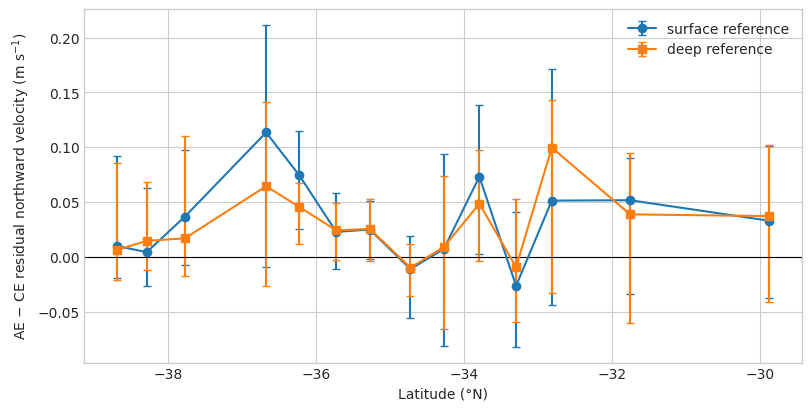

In [14]:
fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)

family = FAMILIES[0]
for reference, marker in (('surface', 'o'), ('deep', 's')):
    q = latitude_contrasts.query('family == @family and reference == @reference').dropna(subset=['ae_minus_ce'])
    ax.errorbar(q.latitude, q.ae_minus_ce, yerr=[q.ae_minus_ce-q.ci_low, q.ci_high-q.ae_minus_ce],
                marker=marker, capsize=3, label=f'{reference} reference')

ax.axhline(0, color='k', lw=.8)
# ax.set_title=f'{family}: latitude-matched AE − CE contrast'
ax.set_xlabel('Latitude (°N)')
ax.set_ylabel('AE − CE residual northward velocity (m s$^{-1}$)')
ax.legend()
plt.show()

## 8. Direct propagation of eddy centres at fixed depths

This is the stronger test. `tilt.load_vert()` contains fitted centre positions through the water column. Centres are interpolated to fixed physical depths (0, 200 and 500 m), differentiated along each eddy track, smoothed over five observations, and rotated from the model grid into geographic east/north. A positive `0 m − 500 m` eastward velocity difference means the shallow centre propagates farther east (or less westward) than the deep centre and directly predicts eastward tilt growth.

,centre_east_ms_0m,centre_east_ms_200m,centre_east_ms_500m,centre_north_ms_0m,centre_north_ms_200m,centre_north_ms_500m,direct_surface_minus_500_east_ms,direct_surface_minus_500_north_ms
Cyc,,,,,,,,
AE,-0.0074,-0.0113,-0.0135,-0.0042,-0.0055,-0.0066,0.0057,0.0017
CE,-0.0307,-0.0259,-0.0255,-0.0161,-0.0093,-0.0111,-0.0036,-0.0029


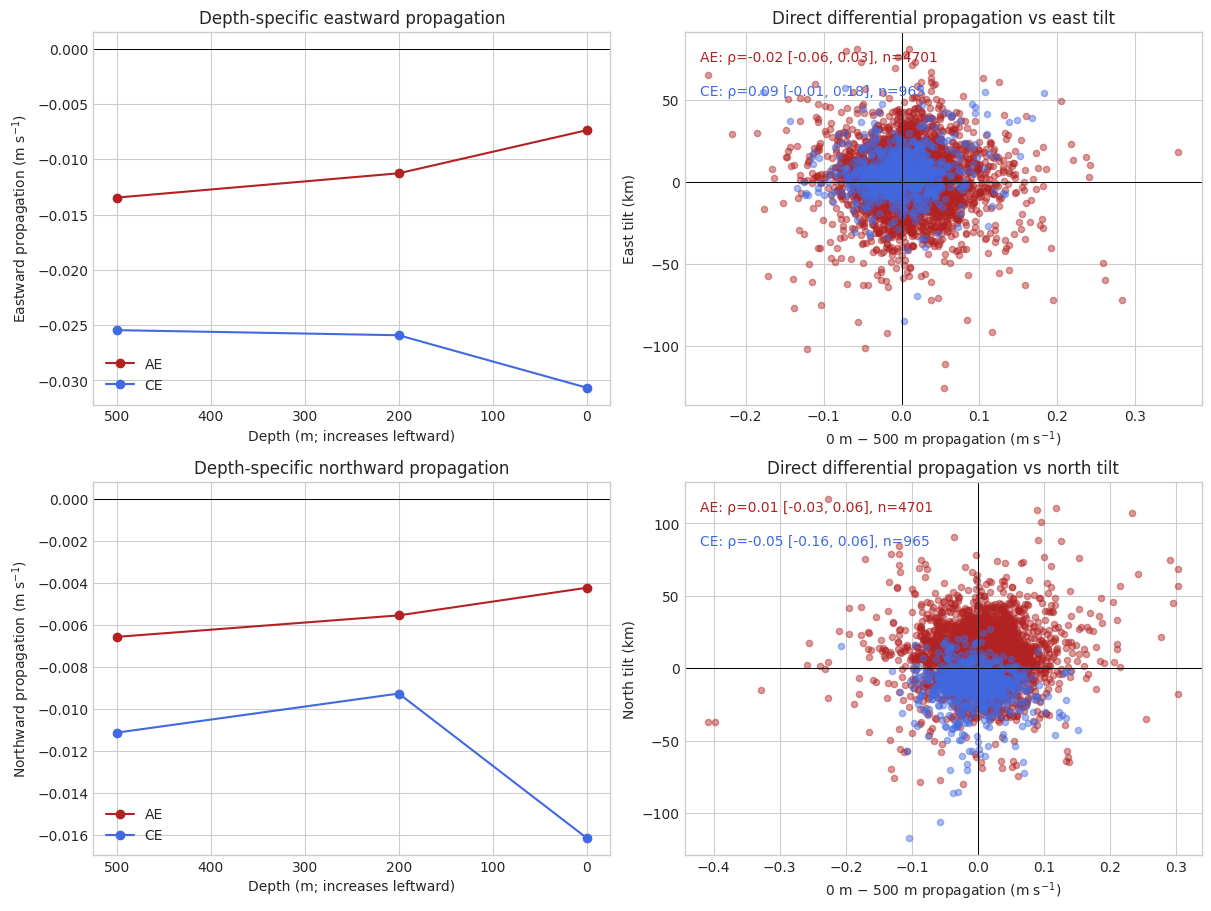

In [15]:
vertical = tilt.load_vert(paths)
centres = interpolate_centres(vertical, target_depths=(0.0, 200.0, 500.0))
centres = add_depth_propagation(centres, grid.angle, window=5)
depth_motion = wide_depth_propagation(centres)
planetary = planetary.merge(depth_motion, on=['Eddy','Day'], how='left', validate='one_to_one')
for component in ('east', 'north'):
    planetary[f'direct_surface_minus_500_{component}_ms'] = (
        planetary[f'centre_{component}_ms_0m'] - planetary[f'centre_{component}_ms_500m'])
    planetary[f'direct_surface_minus_200_{component}_ms'] = (
        planetary[f'centre_{component}_ms_0m'] - planetary[f'centre_{component}_ms_200m'])

direct_cols = [f'centre_{c}_ms_{z}m' for c in ('east','north') for z in (0,200,500)] + [
    f'direct_surface_minus_500_{c}_ms' for c in ('east','north')]
direct_data = planetary
display(direct_data.groupby('Cyc')[direct_cols].median().round(4))

fig, axes = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)
for i, component in enumerate(('east','north')):
    ax = axes[i,0]
    for cyc in ('AE','CE'):
        q = direct_data[direct_data.Cyc.eq(cyc)]
        med = [q[f'centre_{component}_ms_{z}m'].median() for z in (0,200,500)]
        ax.plot((0,200,500), med, 'o-', color=colors[cyc], label=cyc)
    ax.axhline(0,color='k',lw=.7); ax.invert_xaxis()
    ax.set(xlabel='Depth (m; increases leftward)', ylabel=f'{component.capitalize()}ward propagation (m s$^{{-1}}$)',
           title=f'Depth-specific {component}ward propagation')
    ax.legend()
    ax = axes[i,1]
    x = f'direct_surface_minus_500_{component}_ms'
    y = f'tilt_{component}_km'
    for cyc in ('AE','CE'):
        q = direct_data[direct_data.Cyc.eq(cyc)].dropna(subset=[x,y])
        ax.scatter(q[x], q[y], s=20, alpha=.45, color=colors[cyc], label=cyc)
        rho, lo, hi = cluster_bootstrap_correlation(q, x, y, seed=RANDOM_SEED + i)
        ax.text(.03, .95-(.09 if cyc=='CE' else 0), f'{cyc}: ρ={rho:.2f} [{lo:.2f}, {hi:.2f}], n={len(q)}',
                transform=ax.transAxes, va='top', color=colors[cyc])
    ax.axhline(0,color='k',lw=.7); ax.axvline(0,color='k',lw=.7)
    ax.set(xlabel='0 m − 500 m propagation (m s$^{-1}$)', ylabel=f'{component.capitalize()} tilt (km)',
           title=f'Direct differential propagation vs {component} tilt')
plt.show()

## 9. Interpretation guide

Evidence consistent with the proposed zonal mechanism would require: (1) surface-minus-deep eastward flow is positive for both AE and CE, with eddy-cluster bootstrap confidence intervals excluding zero; (2) the result agrees between the moving seasonal climatology and full-archive background; (3) observations with stronger eastward shear tend to have larger eastward tilt; (4) shear at one observation predicts subsequent eastward tilt development within the same uninterrupted planetary episode; (5) the direct 0 m minus 500 m centre-propagation difference is eastward and predicts eastward tilt or tilt growth; and (6) the relationship is not explained by latitude.

For the environmental-shear test in raw geographic coordinates, a more northward shear should make tilt more northward for both polarities: it strengthens AE equatorward tilt and weakens CE poleward tilt. A weak meridional shear slope alongside a strong AE–CE tilt difference would instead support the interpretation that polarity-dependent beta dynamics set the meridional component. A directional median or sign concordance without a magnitude or temporal association is suggestive of a shared environment, but not evidence that shear causes tilt.

Keep the two tests conceptually separate: the cache describes environmental flow, whereas `load_vert()` provides the fitted centre positions used for direct depth-specific propagation. Agreement between them is much stronger evidence than either alone. Even then, association does not by itself establish causation, and derivatives of fitted daily centres can be noisy; inspect coverage, outliers and individual tracks before drawing a dynamical conclusion.